## 📊 Comprehensive EDA Checklist — Python & Pandas

### 1- Setup — imports (run once)

In [47]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

### 2- Upload data to PostgreSQL

In [48]:
load_dotenv()

DB_SERVER_HOST = os.getenv("POSTGRES_HOST")
POSTGRES_DB = os.getenv("POSTGRES_DB")
POSTGRES_USER = os.getenv("POSTGRES_USER")
POSTGRES_PASSWORD = os.getenv("POSTGRES_PASSWORD")
POSTGRES_PORT = os.getenv("POSTGRES_PORT")

engine = create_engine(
    f"postgresql://{POSTGRES_USER}:{POSTGRES_PASSWORD}@{DB_SERVER_HOST}:{POSTGRES_PORT}/{POSTGRES_DB}"
)


def data_load(path):

    df = pd.read_csv(path)
    table_name = Path(path).stem

    df.to_sql(
        con=engine,
        chunksize=5000,
        index=False,
        if_exists="replace",
        name=table_name,
    )


# Load all dimension and fact tables into db
data_files = [
    "dim_customers.csv",
    "dim_date.csv",
    "dim_hotels.csv",
    "dim_rooms.csv",
    "fact_reservations.csv",
    "fact_room_inventory.csv",
]


for file in data_files:
    file_path = os.path.join(r"D:\Hotel-Performance-Optimizer-V2\notebook", file)
    data_load(file_path)

# Read tables from db


def read_table(table_name):
    return pd.read_sql(f"SELECT * FROM {table_name}", engine)

### 3 - Merging Tables

In [49]:
join_plan = [
    ("dim_customers", "customer_id", "customer_id"),
    ("dim_date", "booking_date_key", "date_key"),
    ("dim_rooms", "room_id", "room_id"),
]

fact_reservations_enrichment = read_table("fact_reservations")


for table_name, table_left_key, table_right_key in join_plan:
    before = len(fact_reservations_enrichment)
    dim_df = read_table(table_name)

    fact_reservations_enrichment = pd.merge(
        fact_reservations_enrichment,
        dim_df,
        how="inner",
        left_on=table_left_key,
        right_on=table_right_key,
    )

    after = len(fact_reservations_enrichment)
    print(f"{table_name}: {before} -> {after} rows.")

dim_customers: 500000 -> 500000 rows.
dim_date: 500000 -> 500000 rows.
dim_rooms: 500000 -> 500000 rows.


In [50]:
join_plan = [
    ("dim_date", "date_key", "date_key"),
    ("dim_hotels", "property_id", "property_id"),
]

fact_room_inventory_enrichment = read_table("fact_room_inventory")

for table_name, left_key, right_key in join_plan:
    before = len(fact_room_inventory_enrichment)
    dim_df = read_table(table_name)
    fact_room_inventory_enrichment = pd.merge(
        fact_room_inventory_enrichment,
        dim_df,
        how="inner",
        left_on=left_key,
        right_on=right_key,
    )
    after = len(fact_room_inventory_enrichment)
    print(f"{table_name}: {before} -> {after} rows")

dim_date: 109600 -> 109600 rows
dim_hotels: 109600 -> 109600 rows


### 4 -  LOAD & INSPECT


In [51]:
# Tables after joins

fact_room_inventory_enrichment.head()

,date_key,property_id,rooms_available,rooms_sold,rooms_out_of_order,occupancy_pct,date,day,month,month_name,...,weekend_flag,property_name,brand,region,country,city,hotel_type,hotel_category,room_capacity,opening_date
0,20230101,38558,185,147,2,79.46,2023-01-01,1,1,January,...,1,Bellamare Riyadh,Bellamare,Middle East,Saudi Arabia,Riyadh,Business District,Premium,187,1985-12-02
1,20230102,38558,187,125,0,66.84,2023-01-02,2,1,January,...,0,Bellamare Riyadh,Bellamare,Middle East,Saudi Arabia,Riyadh,Business District,Premium,187,1985-12-02
2,20230103,38558,186,140,1,75.27,2023-01-03,3,1,January,...,0,Bellamare Riyadh,Bellamare,Middle East,Saudi Arabia,Riyadh,Business District,Premium,187,1985-12-02
3,20230104,38558,185,119,2,64.32,2023-01-04,4,1,January,...,0,Bellamare Riyadh,Bellamare,Middle East,Saudi Arabia,Riyadh,Business District,Premium,187,1985-12-02
4,20230105,38558,186,111,1,59.68,2023-01-05,5,1,January,...,0,Bellamare Riyadh,Bellamare,Middle East,Saudi Arabia,Riyadh,Business District,Premium,187,1985-12-02


In [52]:
fact_reservations_enrichment.head()

,booking_id,customer_id,property_id,room_id,booking_date_key,check_in_date_key,checkout_date_key,booking_channel,market_segment,booking_status,...,quarter,year,week,weekday_flag,weekend_flag,room_class,room_category,base_rate,suite_flag,premium_flag
0,RES700000001,CUST107912,23558,RT3,20230814,20230814,20230818,Velora App,Direct,Cancelled,...,3,2023,33,1,0,Deluxe,Deluxe,169,0,0
1,RES700000002,CUST105885,34560,RT5,20240625,20240705,20240708,Corporate Travel Desk,Corporate,Checked Out,...,2,2024,26,1,0,Executive,Executive,259,0,1
2,RES700000003,CUST114187,36558,RT1,20250426,20250610,20250612,Velora.com,Direct,Checked Out,...,2,2025,17,0,1,Standard,Standard,99,0,0
3,RES700000004,CUST137877,31562,RT7,20241226,20250109,20250110,Velora.com,Direct,Checked Out,...,4,2024,52,1,0,Executive Suite,Suite,459,1,1
4,RES700000005,CUST138800,32558,RT8,20230413,20230413,20230414,OTA - Booking.com,Leisure,Checked Out,...,2,2023,15,1,0,Presidential Suite,Suite,899,1,1


In [53]:
# ---------- STEP 1: First Look at the Data ----------

# Data Overview for first table fact_reservations_enrichment

# def data_overview(path):

# print(path.shape)
# print(path.dtypes)
# path.head(5)
# print(path.describe())
# print(path.select_dtypes(include=["object", "category"]))
# print(fact_reservations_enrichment.nunique())
# fact_reservations_enrichment.info(memory_usage='deep')


# data_overview(fact_reservations_enrichment)

In [54]:
# 2. Data Types & Structure

# I found that the check_in and check_our data type is int64 so I will change it to datetime64 for analysis

fact_reservations_enrichment["check_in_date_key"] = pd.to_datetime(
    fact_reservations_enrichment["check_in_date_key"].astype("str")
)
fact_reservations_enrichment["checkout_date_key"] = pd.to_datetime(
    fact_reservations_enrichment["checkout_date_key"].astype("str")
)
fact_reservations_enrichment["date"] = pd.to_datetime(
    fact_reservations_enrichment["date"].astype("str")
)
fact_reservations_enrichment.dtypes

booking_id                   object
customer_id                  object
property_id                   int64
room_id                      object
booking_date_key              int64
check_in_date_key    datetime64[ns]
checkout_date_key    datetime64[ns]
booking_channel              object
market_segment               object
booking_status               object
guests                        int64
room_revenue                float64
food_revenue                float64
other_revenue               float64
total_revenue               float64
length_of_stay                int64
lead_time_days                int64
customer_name                object
country                      object
nationality                  object
loyalty_member                int64
loyalty_tier                 object
customer_segment             object
date_key                      int64
date                 datetime64[ns]
day                           int64
month                         int64
month_name                  

In [55]:
# I found that several columns had an object dtype, which was taking up too much memory.
# After converting them to category, memory usage dropped from 275 MB to 110 MB.

cols_to_convert = fact_reservations_enrichment[
    [
        "month_name",
        "customer_segment",
        "nationality",
        "country",
        "property_id",
        "room_id",
        "booking_channel",
        "market_segment",
        "booking_status",
        "room_class",
        "room_category",
    ]
]
cols_to_convert = cols_to_convert.astype("category")
fact_reservations_enrichment.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 38 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   booking_id         500000 non-null  object        
 1   customer_id        500000 non-null  object        
 2   property_id        500000 non-null  int64         
 3   room_id            500000 non-null  object        
 4   booking_date_key   500000 non-null  int64         
 5   check_in_date_key  500000 non-null  datetime64[ns]
 6   checkout_date_key  500000 non-null  datetime64[ns]
 7   booking_channel    500000 non-null  object        
 8   market_segment     500000 non-null  object        
 9   booking_status     500000 non-null  object        
 10  guests             500000 non-null  int64         
 11  room_revenue       500000 non-null  float64       
 12  food_revenue       500000 non-null  float64       
 13  other_revenue      500000 non-null  float64 

In [56]:
fact_reservations_enrichment

,booking_id,customer_id,property_id,room_id,booking_date_key,check_in_date_key,checkout_date_key,booking_channel,market_segment,booking_status,...,quarter,year,week,weekday_flag,weekend_flag,room_class,room_category,base_rate,suite_flag,premium_flag
0,RES700000001,CUST107912,23558,RT3,20230814,2023-08-14,2023-08-18,Velora App,Direct,Cancelled,...,3,2023,33,1,0,Deluxe,Deluxe,169,0,0
1,RES700000002,CUST105885,34560,RT5,20240625,2024-07-05,2024-07-08,Corporate Travel Desk,Corporate,Checked Out,...,2,2024,26,1,0,Executive,Executive,259,0,1
2,RES700000003,CUST114187,36558,RT1,20250426,2025-06-10,2025-06-12,Velora.com,Direct,Checked Out,...,2,2025,17,0,1,Standard,Standard,99,0,0
3,RES700000004,CUST137877,31562,RT7,20241226,2025-01-09,2025-01-10,Velora.com,Direct,Checked Out,...,4,2024,52,1,0,Executive Suite,Suite,459,1,1
4,RES700000005,CUST138800,32558,RT8,20230413,2023-04-13,2023-04-14,OTA - Booking.com,Leisure,Checked Out,...,2,2023,15,1,0,Presidential Suite,Suite,899,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,RES700499996,CUST115680,26561,RT7,20240621,2024-06-28,2024-07-01,OTA - Booking.com,Leisure,Cancelled,...,2,2024,25,1,0,Executive Suite,Suite,459,1,1
499996,RES700499997,CUST138036,24560,RT3,20240719,2024-08-02,2024-08-04,OTA - Booking.com,OTA,Cancelled,...,3,2024,29,1,0,Deluxe,Deluxe,169,0,0
499997,RES700499998,CUST129068,31560,RT1,20230228,2023-04-29,2023-04-30,Property Direct,Leisure,Checked Out,...,1,2023,9,1,0,Standard,Standard,99,0,0
499998,RES700499999,CUST106069,30559,RT8,20231114,2023-11-21,2023-11-22,Corporate Travel Desk,Corporate,Checked Out,...,4,2023,46,1,0,Presidential Suite,Suite,899,1,1


In [57]:
# ---------- STEP 2: DATA CLEANING ----------

# Missing Values

fact_reservations_enrichment.isnull().sum()

# Finding : I found the loyalty_tier has 199266, approx 40% of the data is missing. I Will deal with in part 3 predictive phase when creating a Model.

(fact_reservations_enrichment.isnull().mean() * 100).round(2)


# Duplicates

(fact_reservations_enrichment.duplicated().mean() * 100).round(2)

(fact_reservations_enrichment.duplicated(subset=["booking_id"]).mean() * 100).round(2)

np.float64(0.0)

### 5- Univariate Analysis (one column at a time)

In [58]:
fact_reservations_enrichment["booking_status"].value_counts(dropna=False)

booking_status
Checked Out    365035
Cancelled       99681
No Show         34769
Confirmed         515
Name: count, dtype: int64

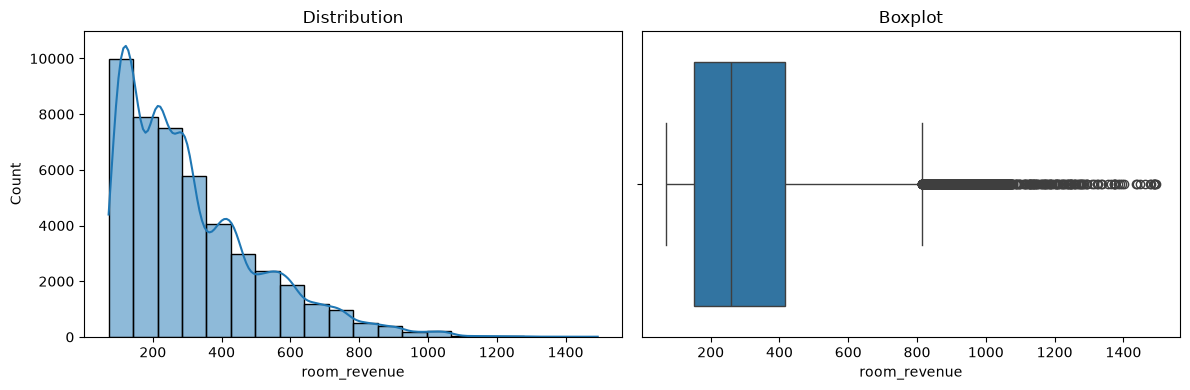

Mean: 311.50
Median: 260.58
Skew: 1.29
Standard  Division: 200.96
Kurtosis: 1.79


In [59]:
# ---------- STEP 3: Univariate Analysis (one column at a time) ----------

# Part 1 : Room Revenue per room pool

fact_reservations_enrichment["booking_status"].value_counts()

data_com = fact_reservations_enrichment[
    ~fact_reservations_enrichment["booking_status"].isin(["Cancelled", "No Show"])
    & fact_reservations_enrichment["room_id"].isin(["RT1"])
].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=(data_com["room_revenue"]), bins=20, kde=True, ax=axes[0])

axes[0].set_title("Distribution")

sns.boxplot(x=(data_com["room_revenue"]), ax=axes[1])

axes[1].set_title("Boxplot")
plt.tight_layout()
plt.show()

print(f"Mean: {data_com['room_revenue'].mean():.2f}")
print(f"Median: {data_com['room_revenue'].median():.2f}")
print(f"Skew: {data_com['room_revenue'].skew():.2f}")
print(f"Standard  Division: {data_com['room_revenue'].std():.2f}")
print(f"Kurtosis: {(data_com['room_revenue']).kurt():.2f}")

In [60]:
# Part 2 : Outlier Detection

Q1 = data_com["room_revenue"].quantile(0.25)
Q3 = data_com["room_revenue"].quantile(0.75)
IQR = Q3 - Q1

lower, upper = Q1 - (1.5 * IQR), Q3 + (1.5 * IQR)

outliers = data_com[
    (data_com["room_revenue"] < lower) | (data_com["room_revenue"] > upper)
]
print(f"Outliers: {len(outliers):,} ({len(outliers)/len(data_com)*100:.2f}%)")
print(f"Fences → lower: {lower:.2f}, upper: {upper:.2f}")

Outliers: 1,189 (2.58%)
Fences → lower: -247.48, upper: 813.27


In [62]:
outliers

,booking_id,customer_id,property_id,room_id,booking_date_key,check_in_date_key,checkout_date_key,booking_channel,market_segment,booking_status,...,quarter,year,week,weekday_flag,weekend_flag,room_class,room_category,base_rate,suite_flag,premium_flag
196,RES700000197,CUST124571,28563,RT1,20240704,2024-07-11,2024-07-15,Velora.com,Leisure,Checked Out,...,3,2024,27,1,0,Standard,Standard,99,0,0
644,RES700000645,CUST119742,40559,RT1,20230329,2023-04-12,2023-04-18,Velora.com,Direct,Checked Out,...,1,2023,13,1,0,Standard,Standard,99,0,0
819,RES700000820,CUST103273,24561,RT1,20240603,2024-07-03,2024-07-10,Velora App,Leisure,Checked Out,...,2,2024,23,1,0,Standard,Standard,99,0,0
1708,RES700001709,CUST108190,26562,RT1,20250905,2025-09-07,2025-09-14,GDS - Corporate,Corporate,Checked Out,...,3,2025,36,1,0,Standard,Standard,99,0,0
1949,RES700001950,CUST101657,28562,RT1,20250524,2025-06-03,2025-06-09,Velora App,Direct,Checked Out,...,2,2025,21,0,1,Standard,Standard,99,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498464,RES700498465,CUST149174,22561,RT1,20230118,2023-01-28,2023-02-04,Velora App,Leisure,Checked Out,...,1,2023,3,1,0,Standard,Standard,99,0,0
498903,RES700498904,CUST147797,30560,RT1,20251029,2025-12-13,2025-12-19,Velora App,Leisure,Checked Out,...,4,2025,44,1,0,Standard,Standard,99,0,0
499744,RES700499745,CUST122470,27563,RT1,20250623,2025-06-25,2025-07-01,Corporate Travel Desk,Corporate,Checked Out,...,2,2025,26,1,0,Standard,Standard,99,0,0
499859,RES700499860,CUST131460,40559,RT1,20251111,2025-11-14,2025-11-19,Velora.com,Direct,Checked Out,...,4,2025,46,1,0,Standard,Standard,99,0,0


In [69]:
# Part 3 — Outlier Decision

outliers.assign(
    adr = lambda d: d["room_revenue"] / d["length_of_stay"]
)[["room_revenue", "length_of_stay", "adr"]].describe()

# Inspect the biggest ones
# outliers.nlargest(10, "room_revenue")[["room_revenue", "length_of_stay"]]


,room_revenue,length_of_stay,adr
count,1189.000000,1189.000000,1189.000000
mean,946.679268,6.084104,158.177877
std,122.817913,0.846656,26.568672
min,813.370000,4.000000,116.272857
25%,856.530000,6.000000,139.142857
50%,909.030000,6.000000,149.070000
75%,1010.150000,7.000000,179.434000
max,1493.420000,7.000000,213.573333


In [64]:
outliers.nlargest(10, "room_revenue")[["room_revenue", "length_of_stay"]]

,room_revenue,length_of_stay
211529,1493.42,7
819,1490.92,7
425133,1487.85,7
374741,1487.64,7
349547,1487.58,7
273238,1480.67,7
378759,1477.95,7
463895,1463.33,7
386250,1448.01,7
150855,1440.63,7


In [72]:
outliers

,booking_id,customer_id,property_id,room_id,booking_date_key,check_in_date_key,checkout_date_key,booking_channel,market_segment,booking_status,...,quarter,year,week,weekday_flag,weekend_flag,room_class,room_category,base_rate,suite_flag,premium_flag
196,RES700000197,CUST124571,28563,RT1,20240704,2024-07-11,2024-07-15,Velora.com,Leisure,Checked Out,...,3,2024,27,1,0,Standard,Standard,99,0,0
644,RES700000645,CUST119742,40559,RT1,20230329,2023-04-12,2023-04-18,Velora.com,Direct,Checked Out,...,1,2023,13,1,0,Standard,Standard,99,0,0
819,RES700000820,CUST103273,24561,RT1,20240603,2024-07-03,2024-07-10,Velora App,Leisure,Checked Out,...,2,2024,23,1,0,Standard,Standard,99,0,0
1708,RES700001709,CUST108190,26562,RT1,20250905,2025-09-07,2025-09-14,GDS - Corporate,Corporate,Checked Out,...,3,2025,36,1,0,Standard,Standard,99,0,0
1949,RES700001950,CUST101657,28562,RT1,20250524,2025-06-03,2025-06-09,Velora App,Direct,Checked Out,...,2,2025,21,0,1,Standard,Standard,99,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498464,RES700498465,CUST149174,22561,RT1,20230118,2023-01-28,2023-02-04,Velora App,Leisure,Checked Out,...,1,2023,3,1,0,Standard,Standard,99,0,0
498903,RES700498904,CUST147797,30560,RT1,20251029,2025-12-13,2025-12-19,Velora App,Leisure,Checked Out,...,4,2025,44,1,0,Standard,Standard,99,0,0
499744,RES700499745,CUST122470,27563,RT1,20250623,2025-06-25,2025-07-01,Corporate Travel Desk,Corporate,Checked Out,...,2,2025,26,1,0,Standard,Standard,99,0,0
499859,RES700499860,CUST131460,40559,RT1,20251111,2025-11-14,2025-11-19,Velora.com,Direct,Checked Out,...,4,2025,46,1,0,Standard,Standard,99,0,0


In [77]:
long_stay = data_com["length_of_stay"] >= 4

data_com.groupby(long_stay).agg(
rows = ("room_revenue", "size"),
revenue = ("room_revenue", "sum"),
avg_los = ("length_of_stay", "mean"),
)

,rows,revenue,avg_los
length_of_stay,,,
False,34313,7571313.97,1.852825
True,11706,6763430.03,4.849308
